<a href="https://colab.research.google.com/github/swgriggs2/st554-homework6/blob/main/st554-hw6-griggs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title: ST-554 Homework 6 \
Author: Stephen Griggs \
Date: 3/5/2026



In [1]:
import pandas as pd
import numpy as np
#from numpy.random import default_rng
#from sklearn.linear_model import LinearRegression
#from plotnine import *
import requests
import sqlite3

# Part 1: Querying a Database

## Problem 1

In [2]:
url = "https://github.com/jknecht/baseball-archive-sqlite/releases/download/2022/lahman_1871-2022.sqlite"

response = requests.get(url)
with open("lahman.sqlite", "wb") as f:
    f.write(response.content)

conn = sqlite3.connect("lahman.sqlite")

In [3]:
tables = pd.read_sql("SELECT * FROM sqlite_master WHERE type='table'", conn)
tables

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


## Problem 2
First I need to know what columns are present in the `HallOfFame` and `Pitching` tables

In [4]:
pd.read_sql("select * from HallOfFame", conn).columns

Index(['playerID', 'yearid', 'votedBy', 'ballots', 'needed', 'votes',
       'inducted', 'category', 'needed_note'],
      dtype='object')

In [5]:
pd.read_sql("select * from Pitching", conn).columns

Index(['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'W', 'L', 'G', 'GS',
       'CG', 'SHO', 'SV', 'IPouts', 'H', 'ER', 'HR', 'BB', 'SO', 'BAOpp',
       'ERA', 'IBB', 'WP', 'HBP', 'BK', 'BFP', 'GF', 'R', 'SH', 'SF', 'GIDP'],
      dtype='object')

Select `playerID` and relevant stat columns from pitchers, join them on players who are in the hall of fame, then store the resulting data frame.

In [6]:
query = """
select distinct Pitching.playerID,
    Pitching.GS,
    Pitching.G,
    Pitching.W,
    Pitching.L,
    Pitching.IPOuts,
    Pitching.CG,
    Pitching.SHO,
    Pitching.SV
from Pitching
join HallOfFame on Pitching.playerID = HallOfFame.playerID
where HallOfFame.inducted = 'Y'
"""

HOF_pitchers = pd.read_sql(query, conn)

In [7]:
HOF_pitchers.groupby("playerID").sum()

,GS,G,W,L,IPouts,CG,SHO,SV
playerID,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32
ansonca01,0,3,0,1,12,0,0,1
becklja01,1,1,0,1,12,0,0,0
bendech01,334,459,212,127,9051,255,40,34
blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11
wrighge01,0,3,0,1,15,0,0,0
wrighha01,8,36,4,4,301,0,0,14


## Problem 3
This query required the `distinct` condition on the select statement since duplicate rows were created by the two join statements. For good measure I went back and added `distinct` to problem 2 as well.

In [8]:
query = """
select distinct Batting.playerID,
    Batting.AB,
    Batting.R,
    Batting.H,
    Batting.HR,
    Batting.RBI,
    Batting.BB,
    Batting.SO
from Batting
join Pitching on Batting.playerID = Pitching.playerID
join HallOfFame on Pitching.playerID = HallOfFame.playerID
where HallOfFame.inducted = 'Y'
"""

HOF_pitcher_batting = pd.read_sql(query, conn)

In [9]:
HOF_pitcher_batting.groupby("playerID").sum()

,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,
alexape01,1810,154,378,11,163.0,77,276.0
ansonca01,10281,1999,3435,97,2075.0,984,330.0
becklja01,9551,1603,2938,87,1581.0,616,526.0
bendech01,1147,102,243,6,116.0,75,143.0
blylebe01,451,19,59,0,25.0,5,193.0
...,...,...,...,...,...,...,...
willivi01,1493,107,248,1,84.0,81,199.0
wrighge01,2873,665,866,11,326.0,68,119.0
wrighha01,813,183,224,4,113.0,37,14.0


## Problem 4

In [10]:
pd.merge(HOF_pitchers.groupby("playerID").sum(),
         HOF_pitcher_batting.groupby("playerID").sum()
         , on="playerID")

,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163.0,77,276.0
ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075.0,984,330.0
becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581.0,616,526.0
bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116.0,75,143.0
blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25.0,5,193.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11,1493,107,248,1,84.0,81,199.0
wrighge01,0,3,0,1,15,0,0,0,2873,665,866,11,326.0,68,119.0
wrighha01,8,36,4,4,301,0,0,14,813,183,224,4,113.0,37,14.0


# Part 2: Classes

## Problem 5

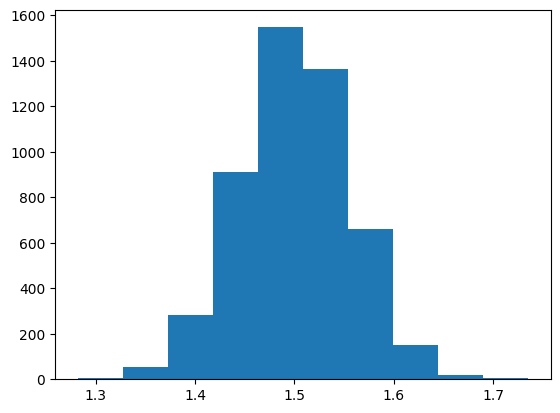

In [14]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)
#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object
#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000):

  #create the 'responses' modeled from the line plus a random deviation
  y = beta_0 + beta_1*x + rng.standard_normal(n)
  #find the least squares solutions and store them
  fit = reg.fit(x.reshape(-1, 1), y)
  beta_array[i, :] = [fit.intercept_, fit.coef_[0]]
#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

In [15]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)

In [ ]:
class Homework6:
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma
        self.x = x
        self.n = len(x)
        self.rng = np.random.default_rng(seed)
        self.slopes = []

    def generate_data(self):
        rng = default_rng(32)
        y = self.beta_0 + self.beta_1*self.x + rng.standard_normal(self.n)
        return (self.x, y)

    def fit_slope(self, x, y):
        reg = linear_model.LinearRegression()
        fit = reg.fit(x.reshape(-1, 1), y)
        return (fit.intercept_, fit.coef_[0])

    def run_simulations(self, n_sim):
        for i in range(n_sim):
            data = self.generate_data()
            self.slopes.append(self.fit_slope(data))

In [11]:
conn.close()